In [1]:
from langchain.chat_models import init_chat_model
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [4]:
@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]

llm = init_chat_model("google_genai:gemini-2.0-flash")
llm_with_tools = llm.bind_tools(tools)

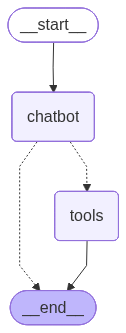

In [7]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
state = graph.invoke({"messages": [{"role": "user", "content": "What is the price of AAPL stock right now?"}]})
print(state["messages"][-1].content)

100.4


In [12]:
state = graph.invoke({"messages": [{"role": "user", "content": "Who invented theory of relativity? print person name only"}]})
print(state["messages"][-1].content)

Albert Einstein


In [13]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]})
print(state["messages"][-1].content)

200.3


In [14]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"
inputs = {"messages": [{"role": "user", "content": msg}]}

for chunk in graph.stream(inputs, stream_mode="debug"):
    print("---- EVENT ----")
    print(chunk)


---- EVENT ----
{'type': 'task', 'timestamp': '2025-11-24T13:09:42.052753+00:00', 'step': 1, 'payload': {'id': '967016f4-ba0c-3222-ed4d-75705bb9a42e', 'name': 'chatbot', 'input': {'messages': [HumanMessage(content='I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?', additional_kwargs={}, response_metadata={}, id='f8b49c41-4860-4190-856e-88ed1d2653d7')]}, 'triggers': ('branch:to:chatbot',)}}
---- EVENT ----
{'type': 'task_result', 'timestamp': '2025-11-24T13:09:43.243191+00:00', 'step': 1, 'payload': {'id': '967016f4-ba0c-3222-ed4d-75705bb9a42e', 'name': 'chatbot', 'error': None, 'result': [('messages', [AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "MSFT"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--4206413f-1d11-40a5-939e-4624fa44963f-0', tool_calls

In [15]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"
inputs = {"messages": [{"role": "user", "content": msg}]}

for step in graph.stream(inputs, stream_mode="values"):
    print("---- STATE UPDATE ----")
    messages = step["messages"]
    print(f"#messages: {len(messages)}")
    print("Last message:", messages[-1])


---- STATE UPDATE ----
#messages: 1
Last message: content='I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?' additional_kwargs={} response_metadata={} id='b7a3d076-2855-48ed-b496-ef4ce0198ece'
---- STATE UPDATE ----
#messages: 2
Last message: content='' additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "MSFT"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--7883de6a-7f7a-4ba7-8bc1-9578ae69a4c6-0' tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'AMZN'}, 'id': '7e4378ca-3ff2-477e-8f61-2616c57442fb', 'type': 'tool_call'}, {'name': 'get_stock_price', 'args': {'symbol': 'MSFT'}, 'id': 'ffd02e28-45eb-4ed7-bfd4-0f5444a51392', 'type': 'tool_call'}] usage_metadata={'input_tokens': 64, 'output_tokens': 16, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}
---- STATE U

In [21]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"
inputs = {"messages": [{"role": "user", "content": msg}]}

for step_i, state in enumerate(graph.stream(inputs, stream_mode="values"), start=1):
    print(f"\n================ STEP {step_i} ================")
    for j, m in enumerate(state["messages"]):
        print(f"\nMessage {j}: {m.__class__.__name__}")
        # type: 'human' | 'ai' | 'tool' (in LC messages)
        print("  type:", getattr(m, "type", None))
        print("  content:", m.content)



================ STEP 1 ================

Message 0: HumanMessage
  type: human
  content: I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?

================ STEP 2 ================

Message 0: HumanMessage
  type: human
  content: I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?

Message 1: AIMessage
  type: ai
  content: 

================ STEP 3 ================

Message 0: HumanMessage
  type: human
  content: I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?

Message 1: AIMessage
  type: ai
  content: 

Message 2: ToolMessage
  type: tool
  content: 150.0

Message 3: ToolMessage
  type: tool
  content: 200.3


In [22]:
from langchain_core.messages import AIMessage

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"
inputs = {"messages": [{"role": "user", "content": msg}]}

for step_i, state in enumerate(graph.stream(inputs, stream_mode="values"), start=1):
    print(f"\n================ STEP {step_i} ================")
    last = state["messages"][-1]

    print("Last message:", last.__class__.__name__)
    print("  type:", getattr(last, "type", None))
    print("  content:", last.content)

    if isinstance(last, AIMessage):
        # How it decided to call tools (this is where AMZN / MSFT get split)
        print("  tool_calls:", getattr(last, "tool_calls", None))
        print("  additional_kwargs:", getattr(last, "additional_kwargs", None))



================ STEP 1 ================
Last message: HumanMessage
  type: human
  content: I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?

================ STEP 2 ================
Last message: AIMessage
  type: ai
  content: 
  tool_calls: [{'name': 'get_stock_price', 'args': {'symbol': 'AMZN'}, 'id': 'af019160-dac5-44e0-b74d-a62d4fb0a3e9', 'type': 'tool_call'}, {'name': 'get_stock_price', 'args': {'symbol': 'MSFT'}, 'id': '935a5c8a-c657-4d5f-82c6-7675c0616617', 'type': 'tool_call'}]
  additional_kwargs: {'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "MSFT"}'}}

================ STEP 3 ================
Last message: ToolMessage
  type: tool
  content: 200.3
